In [710]:

import os
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import librosa.display
import random
import numpy as np
from IPython.display import Audio

In [711]:
POS_PATH = "Datasets/positive"
NEG_PATH = "Datasets/negative"

In [712]:
# Step 3: Extract file info
def extract_info(folder, label):
    data = []
    for file in os.listdir(folder):
        if file.endswith(".wav"):
            path = os.path.join(folder, file)
            try:
                y, sr = librosa.load(path, sr=None, mono=True)
                duration = librosa.get_duration(y=y, sr=sr)
                data.append({
                    "file": file,
                    "label": "Positive" if label==1 else "Negative",
                    "sr": sr,
                    "duration": duration
                })
            except Exception as e:
                print(f" Error {file}: {e}")
    return data

pos_data = extract_info(POS_PATH, 1)
neg_data = extract_info(NEG_PATH, 0)

In [713]:
# convert into data frame and also save this into csv file
df = pd.DataFrame(pos_data + neg_data)

# Save the DataFrame to CSV file
df.to_csv('scream_detection_dataset.csv', index=False)
df.head()


,file,label,sr,duration
0,169810__missozzy__female-scream-01_0.wav,Positive,44100,3.397914
1,169810__missozzy__female-scream-01_1.wav,Positive,44100,3.397914
2,319258__ramston__woman-screaming-of-fear.wav,Positive,16000,16.466687
3,343916__reitanna__screaming-and-why.wav,Positive,16000,10.131438
4,359154__horroraudio__muffled-female-cry.wav,Positive,48000,14.917938


In [714]:
# Step 5: Average Duration
print("Average Duration (all):", df["duration"].mean(), "seconds")
print("Average Duration (Positive):", df[df["label"]=="Positive"]["duration"].mean(), "seconds")
print("Average Duration (Negative):", df[df["label"]=="Negative"]["duration"].mean(), "seconds")

Average Duration (all): 8.718962488899988 seconds
Average Duration (Positive): 5.575342224505543 seconds
Average Duration (Negative): 11.90685909504647 seconds


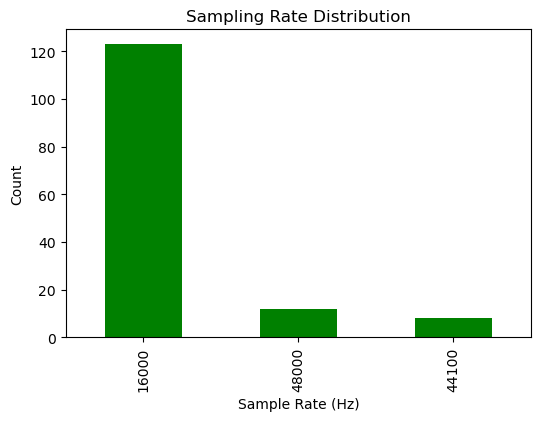

In [715]:
# 🎯 Sampling rate distribution
plt.figure(figsize=(6,4))
df["sr"].value_counts().plot(kind="bar", color="green")
plt.title("Sampling Rate Distribution")
plt.xlabel("Sample Rate (Hz)")
plt.ylabel("Count")
plt.show()


MFCC (Mel Frequency Cepstral Coefficients)

In [716]:
# Pick random one positive and one negative file
pos_file = random.choice(os.listdir(POS_PATH))
neg_file = random.choice(os.listdir(NEG_PATH))

In [717]:
pos_path = os.path.join(POS_PATH, pos_file)
neg_path = os.path.join(NEG_PATH, neg_file)

In [718]:
# Load audio
y_pos, sr_pos = librosa.load(pos_path, sr=None)
y_neg, sr_neg = librosa.load(neg_path, sr=None)

In [719]:
#  Play Audio
print("Positive Sample:", pos_file)
display(Audio(y_pos, rate=sr_pos))

print("Negative Sample:", neg_file)
display(Audio(y_neg, rate=sr_neg))

Positive Sample: femaleScream-065.wav


Negative Sample: clnsp1025.wav


In [720]:
# Extract MFCC
mfcc_pos = librosa.feature.mfcc(y=y_pos, sr=sr_pos, n_mfcc=20)
mfcc_neg = librosa.feature.mfcc(y=y_neg, sr=sr_neg, n_mfcc=20)

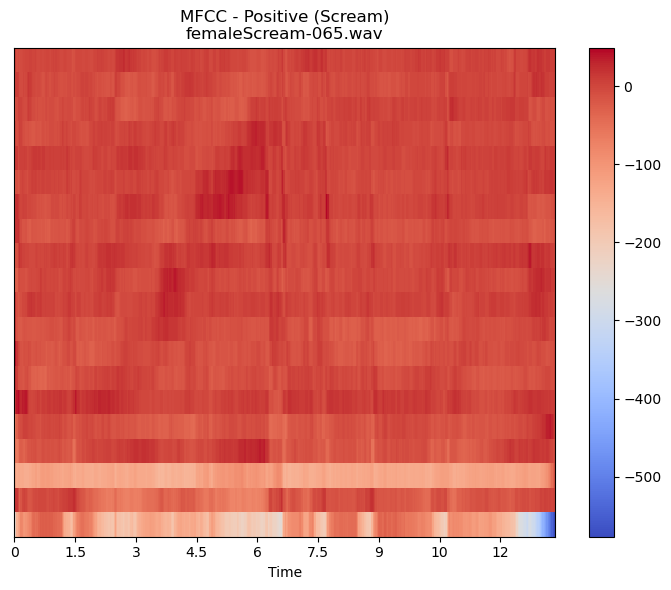

In [721]:
# Plot MFCC heatmaps
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
librosa.display.specshow(mfcc_pos, x_axis='time', sr=sr_pos)
plt.colorbar()
plt.title(f"MFCC - Positive (Scream)\n{pos_file}")
plt.tight_layout()
plt.show()

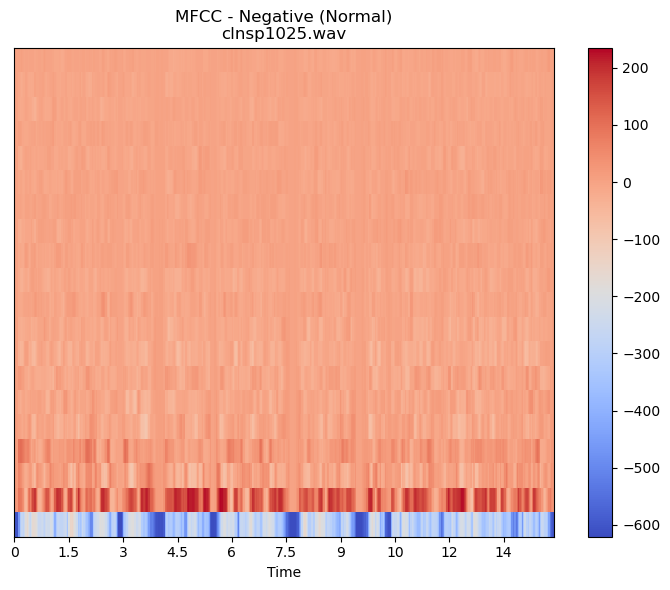

In [722]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,2)
librosa.display.specshow(mfcc_neg, x_axis='time', sr=sr_neg)
plt.colorbar()
plt.title(f"MFCC - Negative (Normal)\n{neg_file}")

plt.tight_layout()
plt.show()

In [723]:
# Zero-Crossing Rate 
zcr_pos = librosa.feature.zero_crossing_rate(y_pos)[0]
zcr_neg = librosa.feature.zero_crossing_rate(y_neg)[0]

# Spectral Centroid 
spec_cent_pos = librosa.feature.spectral_centroid(y=y_pos, sr=sr_pos)[0]
spec_cent_neg = librosa.feature.spectral_centroid(y=y_neg, sr=sr_neg)[0]

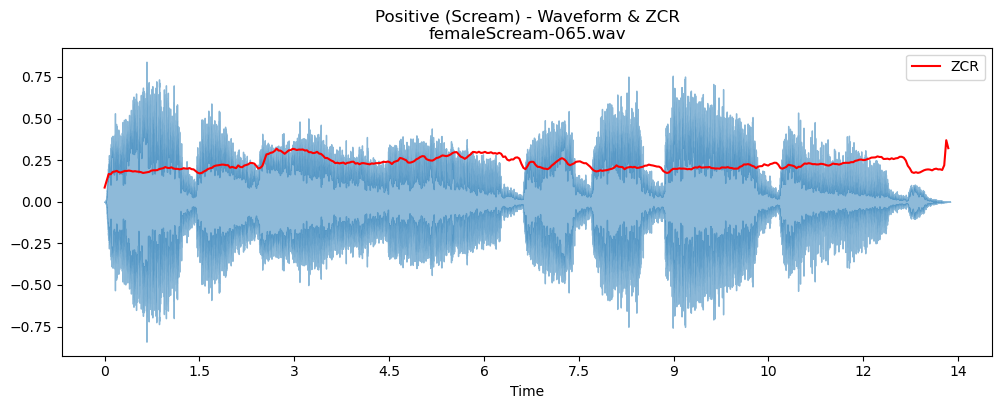

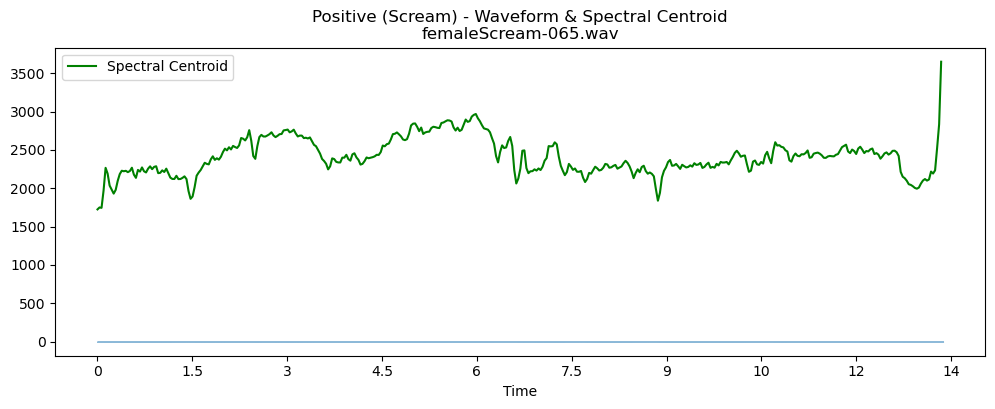

In [724]:
# 1. Positive - waveform and ZCR
plt.figure(figsize=(12, 4))
plt.title(f'Positive (Scream) - Waveform & ZCR\n{pos_file}')
librosa.display.waveshow(y_pos, sr=sr_pos, alpha=0.5)
plt.plot(librosa.times_like(zcr_pos, sr=sr_pos), zcr_pos, color='r', label='ZCR')
plt.legend()
plt.show()

# 2. Positive (Scream) - Waveform & Spectral Centroid
plt.figure(figsize=(12, 4))
plt.title(f'Positive (Scream) - Waveform & Spectral Centroid\n{pos_file}')
librosa.display.waveshow(y_pos, sr=sr_pos, alpha=0.5)
plt.plot(librosa.times_like(spec_cent_pos, sr=sr_pos), spec_cent_pos, color='g', label='Spectral Centroid')
plt.legend()
plt.show()

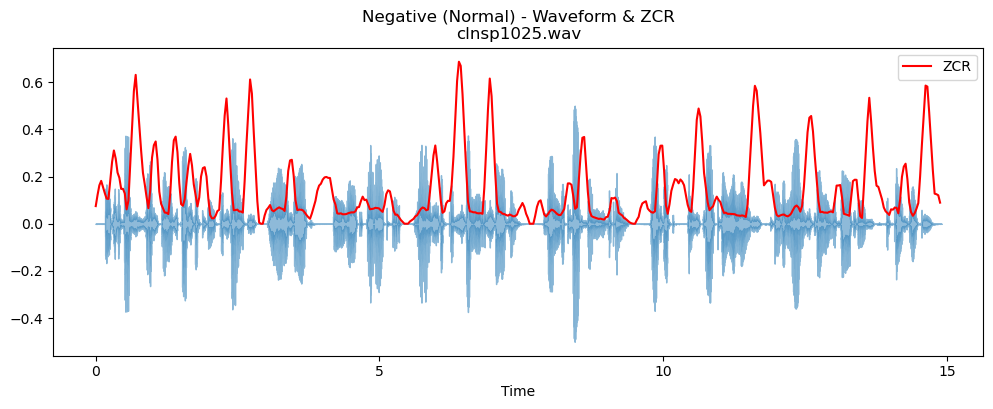

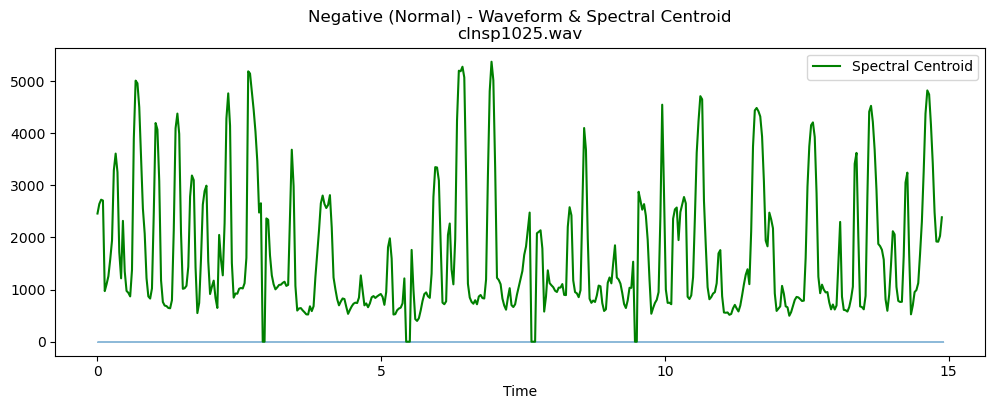

In [725]:
# 3.  Negative (Normal) - Waveform & ZCR
plt.figure(figsize=(12, 4))
plt.title(f'Negative (Normal) - Waveform & ZCR\n{neg_file}')
librosa.display.waveshow(y_neg, sr=sr_neg, alpha=0.5)
plt.plot(librosa.times_like(zcr_neg, sr=sr_neg), zcr_neg, color='r', label='ZCR')
plt.legend()
plt.show()

# 4. Negative (Normal) - Waveform & Spectral Centroid
plt.figure(figsize=(12, 4))
plt.title(f'Negative (Normal) - Waveform & Spectral Centroid\n{neg_file}')
librosa.display.waveshow(y_neg, sr=sr_neg, alpha=0.5)
plt.plot(librosa.times_like(spec_cent_neg, sr=sr_neg), spec_cent_neg, color='g', label='Spectral Centroid')
plt.legend()
plt.show()

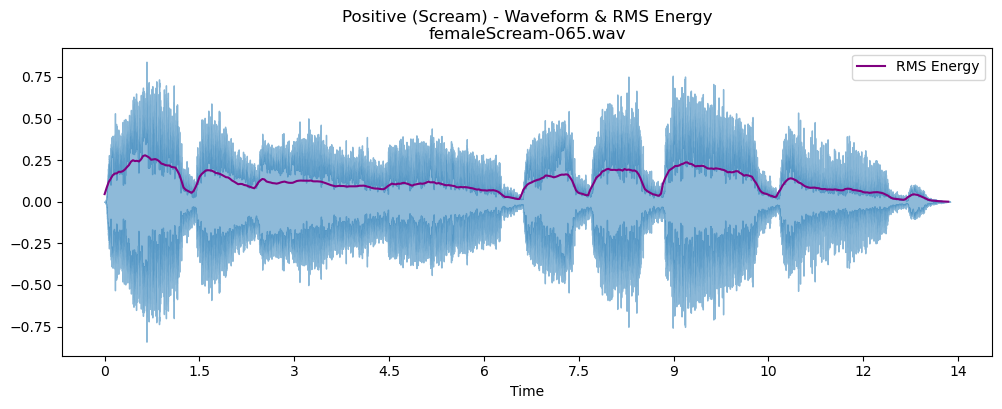

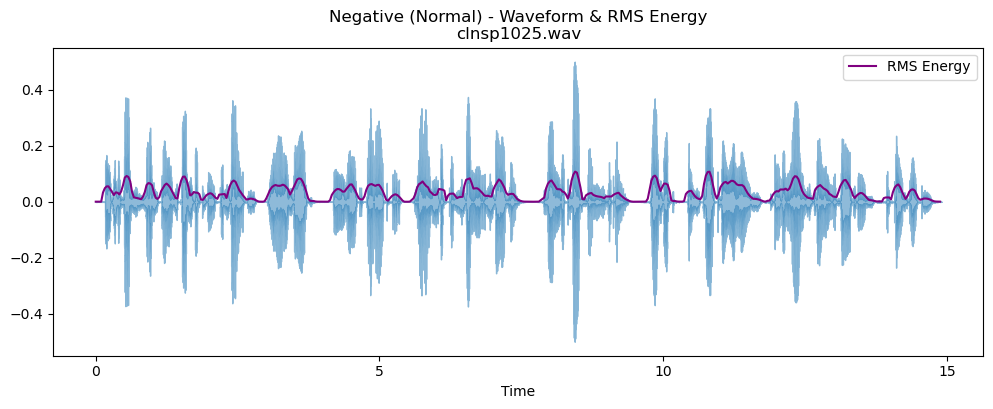

In [726]:
rms_pos = librosa.feature.rms(y=y_pos)[0]
rms_neg = librosa.feature.rms(y=y_neg)[0]

# Positive (Scream) - Waveform & RMS Energy
plt.figure(figsize=(12, 4))
plt.title(f'Positive (Scream) - Waveform & RMS Energy\n{pos_file}')
librosa.display.waveshow(y_pos, sr=sr_pos, alpha=0.5)
plt.plot(librosa.times_like(rms_pos, sr=sr_pos), rms_pos, color='purple', label='RMS Energy')
plt.legend()
plt.show()


# Negative (Normal) - Waveform &    
plt.figure(figsize=(12, 4))
plt.title(f'Negative (Normal) - Waveform & RMS Energy\n{neg_file}')
librosa.display.waveshow(y_neg, sr=sr_neg, alpha=0.5)
plt.plot(librosa.times_like(rms_neg, sr=sr_neg), rms_neg, color='purple', label='RMS Energy')
plt.legend()
plt.show()

In [727]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm


# Function to extract features
def extract_features(file_path, label):
   
    y, sr = librosa.load(file_path, sr=None)

    # 1. MFCCs (take mean of each coefficient)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfccs_mean = np.mean(mfccs, axis=1)

    # 2. Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = np.mean(zcr)

    # 3. RMS Energy
    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)

    # 4. Spectral Centroid
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    centroid_mean = np.mean(centroid)

    # 5. Spectral Bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    bandwidth_mean = np.mean(bandwidth)

    # Collect features
    features = list(mfccs_mean) + [zcr_mean, rms_mean, centroid_mean, bandwidth_mean, label]
    return features

# Columns for dataframe
columns = [f"mfcc_{i}" for i in range(1, 21)] + ["zcr", "rms", "centroid", "bandwidth", "label"]

# Collect all data
data = []

# Positive files
for file in tqdm(os.listdir(POS_PATH), desc="Processing Positive"):
    file_path = os.path.join(POS_PATH, file)
    feat = extract_features(file_path, 1)  # 1 = scream
    if feat:
        data.append(feat)

# Negative files
for file in tqdm(os.listdir(NEG_PATH), desc="Processing Negative"):
    file_path = os.path.join(NEG_PATH, file)
    feat = extract_features(file_path, 0)  # 0 = non-scream
    if feat:
        data.append(feat)

# Create dataframe
df = pd.DataFrame(data, columns=columns)

# Save to CSV
df.to_csv("audio_features.csv", index=False)



Processing Positive:   0%|          | 0/72 [00:00<?, ?it/s]

Processing Negative: 100%|██████████| 71/71 [00:08<00:00,  8.04it/s]


In [728]:
# Calculate mean spectral bandwidth for positive and negative samples
bandwidth_pos = librosa.feature.spectral_bandwidth(y=y_pos, sr=sr_pos)[0]
bandwidth_neg = librosa.feature.spectral_bandwidth(y=y_neg, sr=sr_neg)[0]

print("Mean Bandwidth (Positive):", np.mean(bandwidth_pos))
print("Mean Bandwidth (Negative):", np.mean(bandwidth_neg))

Mean Bandwidth (Positive): 1330.8353478376173
Mean Bandwidth (Negative): 1455.2311648195514


C:\Users\trupe\AppData\Local\Temp\ipykernel_21008\468705337.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="zcr", data=df, palette="coolwarm")


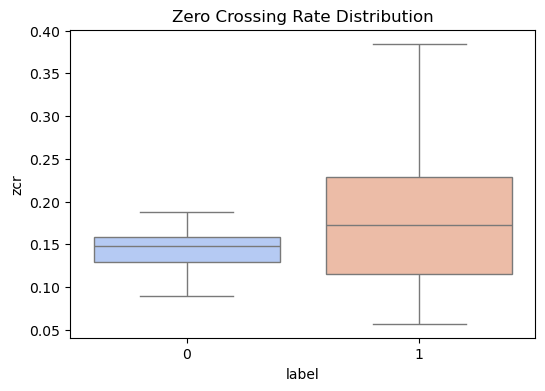

C:\Users\trupe\AppData\Local\Temp\ipykernel_21008\468705337.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="rms", data=df, palette="coolwarm")


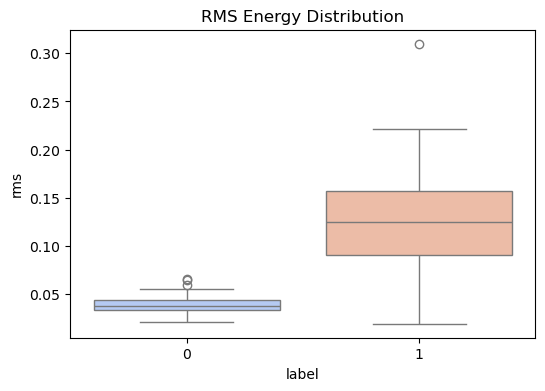

C:\Users\trupe\AppData\Local\Temp\ipykernel_21008\468705337.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="centroid", data=df, palette="coolwarm")


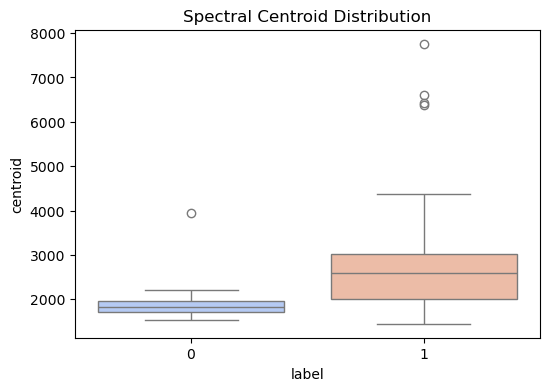

C:\Users\trupe\AppData\Local\Temp\ipykernel_21008\468705337.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="bandwidth", data=df, palette="coolwarm")


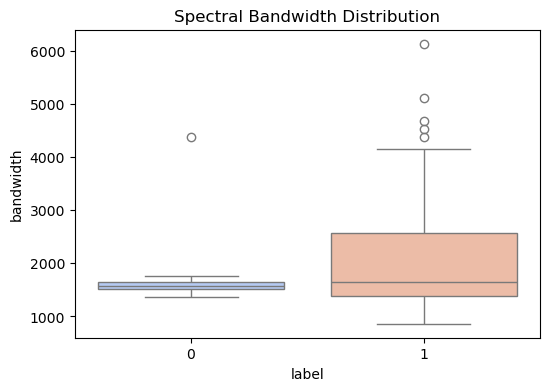

In [729]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load features CSV
df = pd.read_csv("audio_features.csv")


# Compare ZCR
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="zcr", data=df, palette="coolwarm")
plt.title("Zero Crossing Rate Distribution")
plt.show()

# Compare RMS
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="rms", data=df, palette="coolwarm")
plt.title("RMS Energy Distribution")
plt.show()

# Compare Spectral Centroid
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="centroid", data=df, palette="coolwarm")
plt.title("Spectral Centroid Distribution")
plt.show()

# Compare Spectral Bandwidth
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="bandwidth", data=df, palette="coolwarm")
plt.title("Spectral Bandwidth Distribution")
plt.show()



# Logistic regression

In [730]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df_model = pd.read_csv('audio_features.csv')

X = df_model.drop(columns=['label'])
y = df_model['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [731]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [732]:
model = LogisticRegression(tol=0.05, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=6)   
model.fit(X_train_scaled, y_train)


LogisticRegression(random_state=6, tol=0.05)

In [733]:
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))


Model Accuracy: 96.55%

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.93      1.00      0.97        14
Positive (1)       1.00      0.93      0.97        15

    accuracy                           0.97        29
   macro avg       0.97      0.97      0.97        29
weighted avg       0.97      0.97      0.97        29




Confusion Matrix:


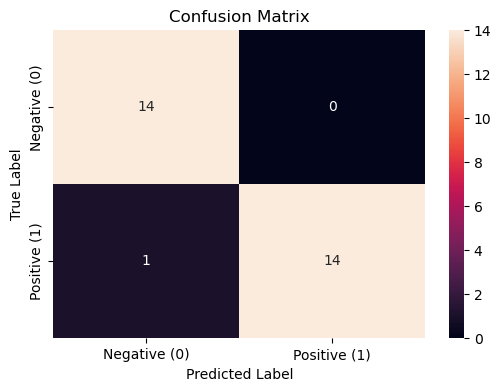

In [734]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Loss Function for the logistice regression

In [735]:
from sklearn.metrics import log_loss

y_pred_proba = model.predict_proba(X_test_scaled)

loss = log_loss(y_test, y_pred_proba)

print("Model Loss Calculation")
print(f"Log Loss: {loss:.4f}")

Model Loss Calculation
Log Loss: 0.1065


Cross Validation

In [736]:
X

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,zcr,rms,centroid,bandwidth
0,-371.81662,15.579487,-77.259560,-26.756735,-35.850735,17.904285,7.287590,13.913341,8.021985,-5.084484,...,-6.202483,10.886309,4.547787,3.287747,-6.661115,-12.176492,0.090100,0.145813,3517.073263,3484.035704
1,-395.63965,37.125446,-39.781082,-25.948720,-31.750263,-7.493671,-7.592010,4.555742,10.240966,6.649177,...,-7.922609,6.296483,7.221046,6.116911,-0.458164,-6.726007,0.114813,0.113743,4199.161276,4151.309046
2,-322.82907,72.819150,-43.873226,0.907010,-4.720170,3.402434,-6.109078,1.931142,7.645120,-2.095681,...,-4.712239,-2.500354,-0.293220,0.197763,-5.375964,-2.669612,0.140982,0.043131,1764.719621,1529.439665
3,-92.74729,-2.126471,-70.459060,-17.510400,-5.420853,3.707529,-3.968467,-6.153053,6.114237,2.005953,...,-2.490692,2.788041,-2.008865,3.373276,1.325794,0.092268,0.205140,0.198559,2615.523982,1783.746771
4,-491.19412,55.544094,0.890635,8.296686,-5.510558,-4.270522,-16.063549,-11.160427,-10.419491,-9.045915,...,-4.919835,-4.476258,-0.280850,1.526558,4.455655,-0.951556,0.172444,0.019284,6607.935537,6129.191791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,-296.02148,94.774025,-7.642852,37.603867,-1.623476,-2.065755,-9.052361,-12.640333,6.923974,-7.433917,...,-2.413813,-3.307059,-3.858810,-3.805317,-4.428299,-4.117072,0.125630,0.029766,1743.407359,1606.530864
139,-297.31488,69.659640,-29.643260,13.272843,-26.661790,-9.501793,-17.943043,-15.645814,-7.272296,-14.155598,...,-3.645080,-4.472070,-5.925420,-4.392216,-5.724046,-3.832229,0.167597,0.038002,1969.961874,1579.601893
140,-267.29645,73.727455,-12.604898,14.858206,-10.107579,-15.250088,-7.333150,-11.956414,-5.888272,-10.809591,...,-10.935210,-4.742212,-11.384411,-4.436604,-3.815934,-4.197455,0.153537,0.047001,1997.590173,1683.028443
141,-291.78880,92.155810,-6.396050,38.110462,-5.847932,-1.265464,-7.172162,-13.082974,6.927703,-5.049542,...,-5.148058,-5.282370,-4.939850,-2.882575,-5.947748,-4.593020,0.130248,0.029718,1729.921149,1599.328045


In [737]:
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.17588602, -0.64562779, -0.64716684, ...,  1.08114778,
         1.20420406,  1.89000347],
       [-1.47059144, -0.21509165,  0.18143367, ...,  0.523993  ,
         1.89545086,  2.66622261],
       [-0.56988014,  0.49814786,  0.09096168, ..., -0.70276349,
        -0.57167944, -0.38371969],
       ...,
       [ 0.11709225,  0.51629782,  0.78226383, ..., -0.63553885,
        -0.33568201, -0.20505446],
       [-0.18589306,  0.8845373 ,  0.9195334 , ..., -0.93578759,
        -0.60694518, -0.30242063],
       [-0.61236564,  0.50917865,  0.7193481 , ..., -0.68006535,
        -0.64201809, -0.34074867]])

In [738]:
scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
print(f"Accuracy for each fold: {scores}")
print(f"\nAverage Accuracy: {np.mean(scores) * 100:.2f}%")
print(f"Standard Deviation: {np.std(scores):.4f}")

Accuracy for each fold: [0.89655172 1.         0.96551724 0.85714286 0.96428571]

Average Accuracy: 93.67%
Standard Deviation: 0.0520


In [739]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(model, X_scaled, y, cv=5)
print(classification_report(y, y_pred_cv, target_names=['Negative (0)', 'Positive (1)']))

              precision    recall  f1-score   support

Negative (0)       0.90      0.99      0.94        71
Positive (1)       0.98      0.89      0.93        72

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143




Cross-Validated Confusion Matrix:


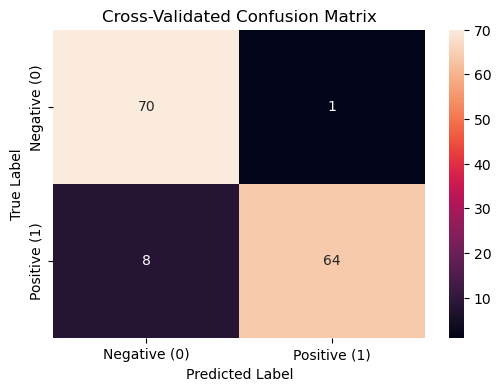

In [740]:
# Confusion Matrix
print("\nCross-Validated Confusion Matrix:")
cm_cv = confusion_matrix(y, y_pred_cv)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_cv, annot=True, fmt='d', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Cross-Validated Confusion Matrix')
plt.show()

Dicision Tree

In [741]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=4, stratify=y)

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=3)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=3)

In [742]:
y_pred_dt = dt_model.predict(X_test)

In [743]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nModel Accuracy: {accuracy_dt * 100:.2f}%")

print(classification_report(y_test, y_pred_dt, target_names=['Negative (0)', 'Positive (1)']))



Model Accuracy: 89.66%
              precision    recall  f1-score   support

Negative (0)       0.87      0.93      0.90        14
Positive (1)       0.93      0.87      0.90        15

    accuracy                           0.90        29
   macro avg       0.90      0.90      0.90        29
weighted avg       0.90      0.90      0.90        29




Confusion Matrix:


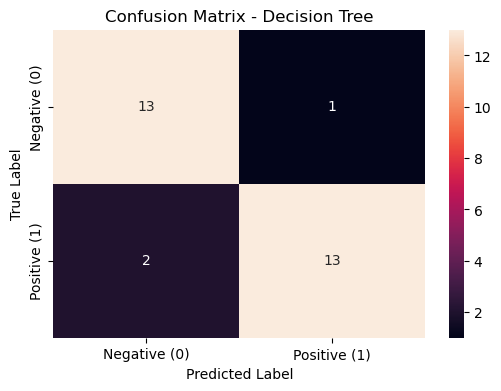

In [744]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

Train the logistic regression on the hole data 

In [745]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [747]:
df_final_model = pd.read_csv('audio_features.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [748]:
X = df_final_model.drop(columns=['label'])
y = df_final_model['label']

In [749]:
X

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,zcr,rms,centroid,bandwidth
0,-371.81662,15.579487,-77.259560,-26.756735,-35.850735,17.904285,7.287590,13.913341,8.021985,-5.084484,...,-6.202483,10.886309,4.547787,3.287747,-6.661115,-12.176492,0.090100,0.145813,3517.073263,3484.035704
1,-395.63965,37.125446,-39.781082,-25.948720,-31.750263,-7.493671,-7.592010,4.555742,10.240966,6.649177,...,-7.922609,6.296483,7.221046,6.116911,-0.458164,-6.726007,0.114813,0.113743,4199.161276,4151.309046
2,-322.82907,72.819150,-43.873226,0.907010,-4.720170,3.402434,-6.109078,1.931142,7.645120,-2.095681,...,-4.712239,-2.500354,-0.293220,0.197763,-5.375964,-2.669612,0.140982,0.043131,1764.719621,1529.439665
3,-92.74729,-2.126471,-70.459060,-17.510400,-5.420853,3.707529,-3.968467,-6.153053,6.114237,2.005953,...,-2.490692,2.788041,-2.008865,3.373276,1.325794,0.092268,0.205140,0.198559,2615.523982,1783.746771
4,-491.19412,55.544094,0.890635,8.296686,-5.510558,-4.270522,-16.063549,-11.160427,-10.419491,-9.045915,...,-4.919835,-4.476258,-0.280850,1.526558,4.455655,-0.951556,0.172444,0.019284,6607.935537,6129.191791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,-296.02148,94.774025,-7.642852,37.603867,-1.623476,-2.065755,-9.052361,-12.640333,6.923974,-7.433917,...,-2.413813,-3.307059,-3.858810,-3.805317,-4.428299,-4.117072,0.125630,0.029766,1743.407359,1606.530864
139,-297.31488,69.659640,-29.643260,13.272843,-26.661790,-9.501793,-17.943043,-15.645814,-7.272296,-14.155598,...,-3.645080,-4.472070,-5.925420,-4.392216,-5.724046,-3.832229,0.167597,0.038002,1969.961874,1579.601893
140,-267.29645,73.727455,-12.604898,14.858206,-10.107579,-15.250088,-7.333150,-11.956414,-5.888272,-10.809591,...,-10.935210,-4.742212,-11.384411,-4.436604,-3.815934,-4.197455,0.153537,0.047001,1997.590173,1683.028443
141,-291.78880,92.155810,-6.396050,38.110462,-5.847932,-1.265464,-7.172162,-13.082974,6.927703,-5.049542,...,-5.148058,-5.282370,-4.939850,-2.882575,-5.947748,-4.593020,0.130248,0.029718,1729.921149,1599.328045


In [750]:
y

0      1
1      1
2      1
3      1
4      1
      ..
138    0
139    0
140    0
141    0
142    0
Name: label, Length: 143, dtype: int64

In [751]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [752]:
model = LogisticRegression(tol=0.05, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=6)
print("\nTraining the Logistic Regression model on the full dataset...")
model.fit(X_scaled, y)
print("Training complete.")


Training the Logistic Regression model on the full dataset...
Training complete.


In [753]:
print("\n--- Evaluating the model on the full training data ---")
y_pred = model.predict(X_scaled)
y_pred_proba = model.predict_proba(X_scaled)



--- Evaluating the model on the full training data ---


In [754]:
# Accuracy
accuracy = accuracy_score(y, y_pred)
print(f"\nModel Accuracy on full data: {accuracy * 100:.2f}%")


Model Accuracy on full data: 97.20%


In [755]:
# Log Loss
loss = log_loss(y, y_pred_proba)
print(f"Log Loss on full data: {loss:.4f}")

Log Loss on full data: 0.1121


In [756]:
# Classification Report
print("\nClassification Report on full data:")
print(classification_report(y, y_pred, target_names=['Negative (0)', 'Positive (1)']))
    


Classification Report on full data:
              precision    recall  f1-score   support

Negative (0)       0.96      0.99      0.97        71
Positive (1)       0.99      0.96      0.97        72

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143




Confusion Matrix on full data:


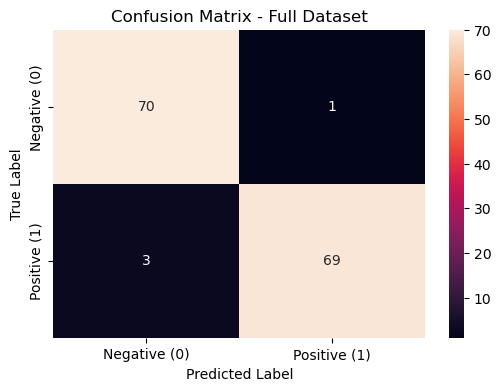

In [757]:
# Confusion Matrix
print("\nConfusion Matrix on full data:")
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Full Dataset')
plt.show()

In [758]:
# save model and scaler
joblib.dump(model, 'models/logistic_regression_model.joblib')
joblib.dump(scaler, 'models/scaler_logistic.joblib') 
    

['models/scaler_logistic.joblib']